In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import xgboost as xgb
import matplotlib.colors as mcolors

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error

from pandas.tseries.holiday import USFederalHolidayCalendar
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from IPython.display import display, HTML

# Initialize seaborn settings
sns.set()

In [3]:
path= 'train.csv'
data= pd.read_csv(path)
df= data.copy()

### EDA

In [4]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [5]:
df.shape

(913000, 4)

In [6]:
df.isna().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [7]:
df.index

RangeIndex(start=0, stop=913000, step=1)

In [8]:
df.dtypes

date     object
store     int64
item      int64
sales     int64
dtype: object

In [9]:
df['date']= pd.DatetimeIndex(df['date'])

In [10]:
cols = ['store', 'item']
html_str = "<div style='display: flex; gap: 20px;'>"

for col in cols:
    # .sort_index() organizes the labels numerically or alphabetically
    table_html = df[col].value_counts().sort_index().to_frame().to_html()
    html_str += f"<div><h3>{col}</h3>{table_html}</div>"

html_str += "</div>"
display(HTML(html_str))

,count
store,
1,91300
2,91300
3,91300
4,91300
5,91300
6,91300
7,91300
8,91300
9,91300


In [11]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [12]:
# check for every single day, that store x holds a record of sales for all of its items .
c= df.groupby(['date','store'])['item'].count()
print('nb of observations of items per store at any given day:',c.mean())

nb of observations of items per store at any given day: 50.0


**Investigating any missing days records**

In [13]:
expected_dates = pd.date_range(start='2013-01-01', end='2017-12-31')
# Compare unique dates in your data to the reference
missing_dates = expected_dates.difference(df['date'].unique())
print(f"Number of missing days: {len(missing_dates)}")

Number of missing days: 0


In [14]:
df =df.set_index('date')
df.head(3)

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14


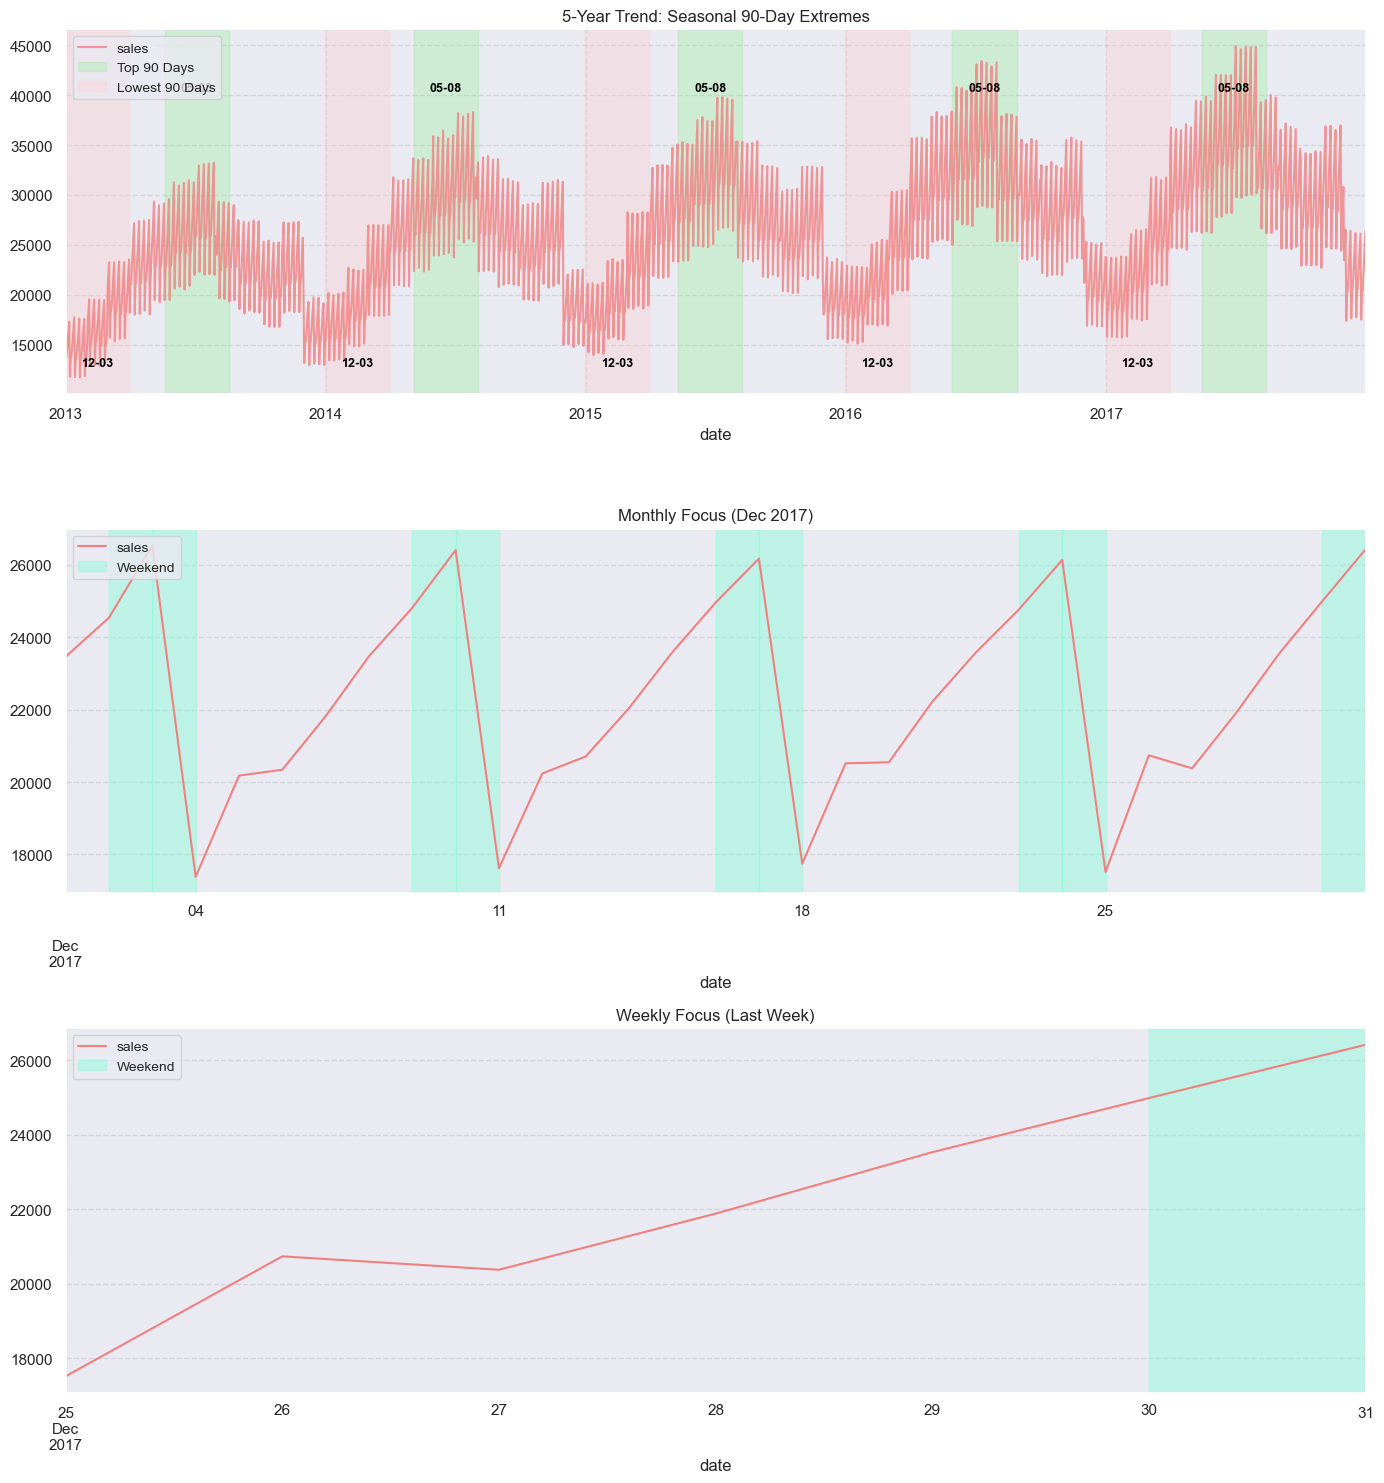

In [15]:
# 1. Aggregate daily sales
daily_sales = df['sales'].resample('D').sum()

# 2. Setup Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 15))
red_milk = '#F08080'
gray_cool = '#808080'
aqua_highlight = '#7FFFD4'
low_red = '#FFCCCB'    
high_green = '#90EE90' 

# --- Graph 1: 5-Year Trend with Peak/Low Windows & Text ---
daily_sales.plot(ax=axes[0], color=red_milk, title='5-Year Trend: Seasonal 90-Day Extremes', alpha=0.8)

for year in range(2013, 2018):
    year_data = daily_sales[str(year)]
    rolling_90 = year_data.rolling(window=90).sum()
    
    # End dates and start dates
    peak_end, low_end = rolling_90.idxmax(), rolling_90.idxmin()
    peak_start, low_start = peak_end - pd.Timedelta(days=90), low_end - pd.Timedelta(days=90)
    
    # Text labels (MM - MM)
    peak_label = f"{peak_start.strftime('%m')}-{peak_end.strftime('%m')}"
    low_label = f"{low_start.strftime('%m')}-{low_end.strftime('%m')}"
    
    # Highs
    axes[0].axvspan(peak_start, peak_end, color=high_green, alpha=0.3, label='Top 90 Days' if year == 2013 else "")
    axes[0].text(peak_start + (peak_end - peak_start)/2, daily_sales.max()*0.9, peak_label, 
                 color='black', weight='bold', ha='center', fontsize=9)
    
    # Lows
    axes[0].axvspan(low_start, low_end, color=low_red, alpha=0.3, label='Lowest 90 Days' if year == 2013 else "")
    axes[0].text(low_start + (low_end - low_start)/2, daily_sales.min()*1.1, low_label, 
                 color='black', weight='bold', ha='center', fontsize=9)

# --- Graph 2: December 2017 & Weekends ---
dec_sales = daily_sales['2017-12']
dec_sales.plot(ax=axes[1], color=red_milk, title='Monthly Focus (Dec 2017)')
weekends = dec_sales.index[dec_sales.index.weekday >= 5]
for i, day in enumerate(weekends):
    axes[1].axvspan(day, day + pd.Timedelta(days=1), color=aqua_highlight, alpha=0.4, label='Weekend' if i == 0 else "")

# --- Graph 3: Last Week & Weekends ---
last_week_sales = daily_sales['2017-12-25':]
last_week_sales.plot(ax=axes[2], color=red_milk, title='Weekly Focus (Last Week)')
lw_weekends = last_week_sales.index[last_week_sales.index.weekday >= 5]
for i, day in enumerate(lw_weekends):
    axes[2].axvspan(day, day + pd.Timedelta(days=1), color=aqua_highlight, alpha=0.4, label='Weekend' if i == 0 else "")

# Global Formatting
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.2, color=gray_cool)
    ax.legend(loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

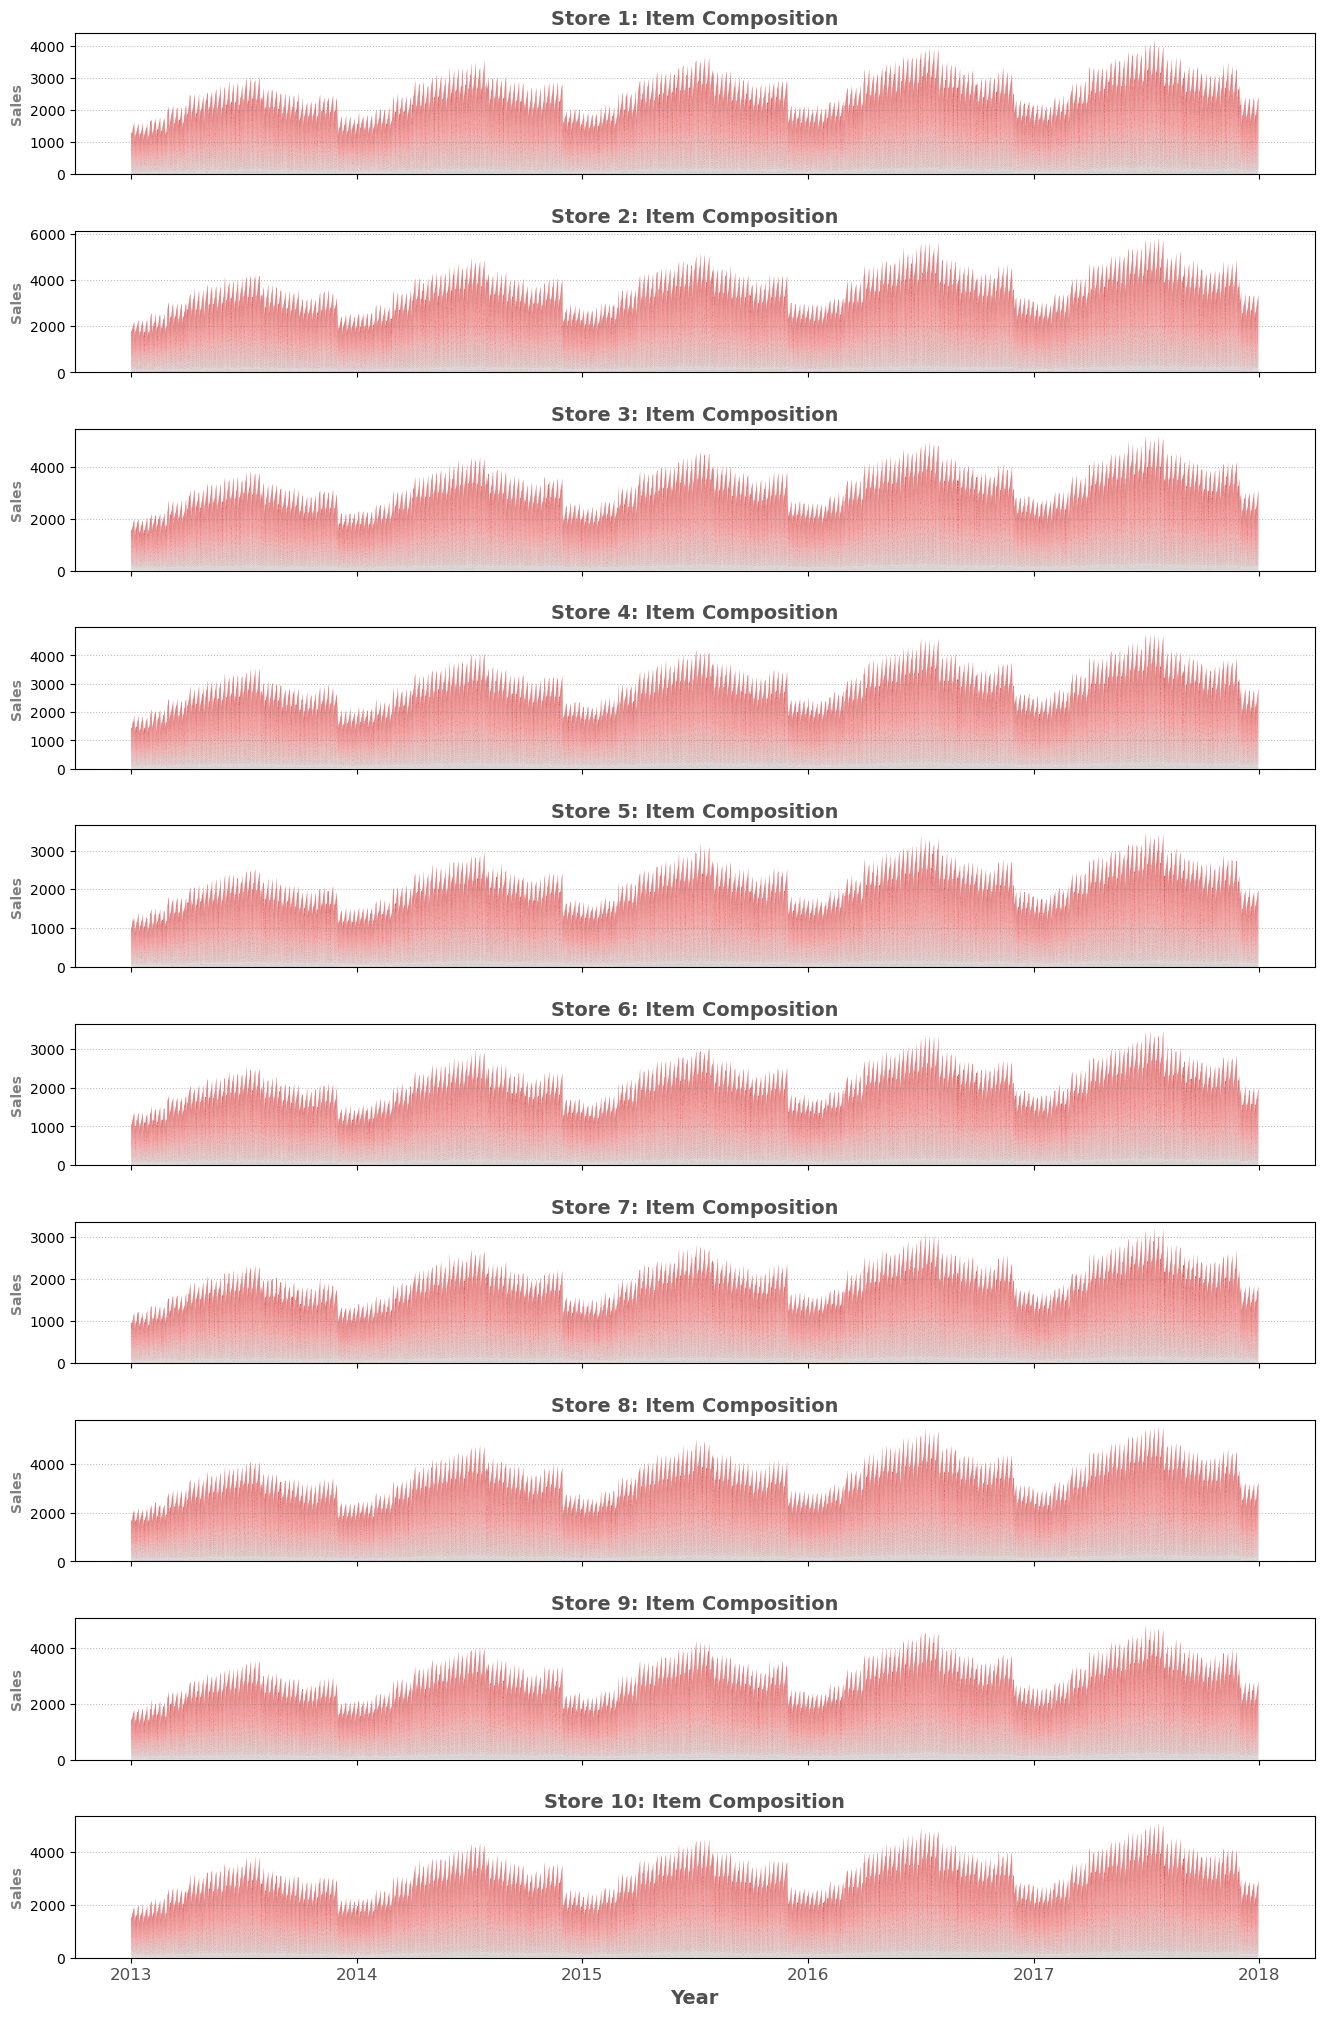

In [16]:
# 1. Force a clean white background
plt.style.use('default') 

# 2. Create a sharper Gradient
# Using a darker Red ('#D64545') to ensure visibility against white
colors = mcolors.LinearSegmentedColormap.from_list("custom_grad", ['#D3D3D3', '#F08080', '#D64545'])
item_colors = [colors(i/50) for i in range(50)]

# 3. Setup Figure
fig, axes = plt.subplots(10, 1, figsize=(16, 25), sharex=True, facecolor='white')
plt.subplots_adjust(hspace=0.4)

for store_id in range(1, 11):
    ax = axes[store_id - 1]
    ax.set_facecolor('white') # Ensure subplot background is white
    
    # Pivot data
    store_df = df[df['store'] == store_id].pivot(columns='item', values='sales')
    
    # Plot using stackplot - Removing 'edgecolor' prevents the "gray haze"
    ax.stackplot(store_df.index, store_df.values.T, 
                 colors=item_colors, 
                 alpha=1.0, 
                 edgecolor='none') 
    
    # Formatting
    ax.set_title(f'Store {store_id}: Item Composition', color='#4F4F4F', fontsize=14, fontweight='bold')
    ax.set_ylabel('Sales', color='#808080', fontweight='bold')
    ax.grid(True, axis='y', linestyle=':', alpha=0.5, color='gray')

# 4. Handle X-Axis (Yearly Ticks)
years = pd.date_range(start='2013-01-01', end='2018-01-01', freq='YS')
axes[-1].set_xticks(years)
axes[-1].set_xticklabels([date.year for date in years], color='#4F4F4F', fontsize=12)
axes[-1].set_xlabel('Year', fontsize=14, color='#4F4F4F', fontweight='bold')

plt.show()

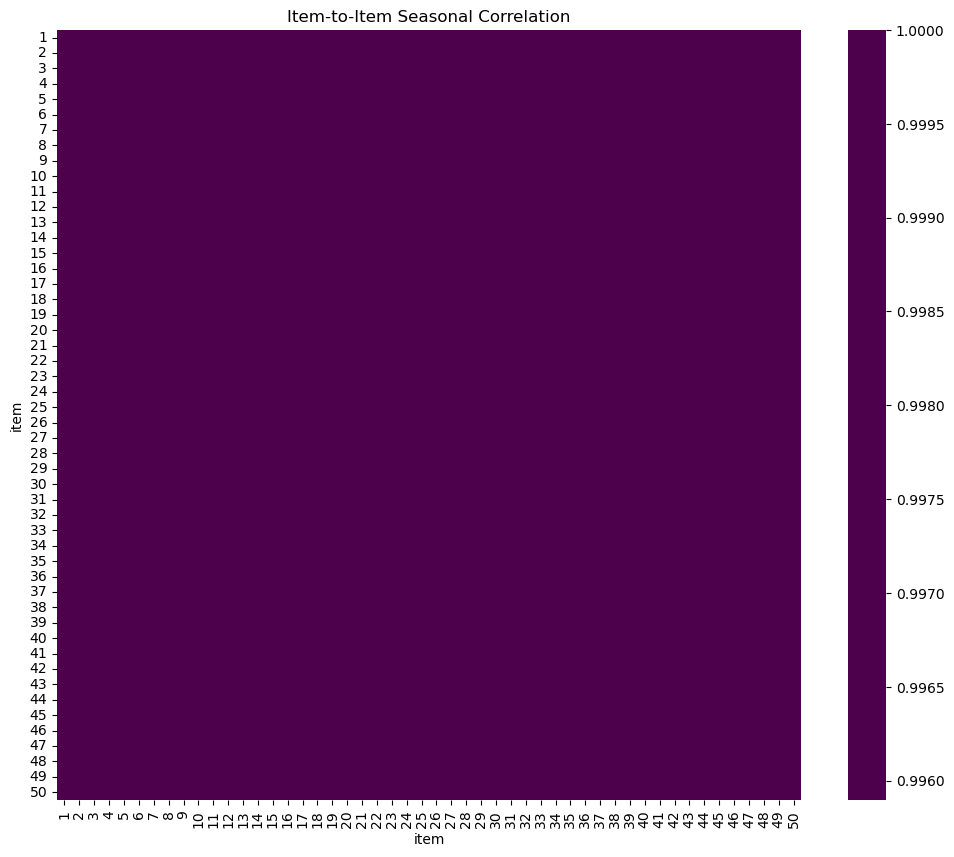

In [17]:
# 1. Pivot: Columns = Items, Rows = Months, Values = Sum of Sales
item_monthly_sales = df.pivot_table(index=df.index.to_period('M'), 
                                    columns='item', 
                                    values='sales', 
                                    aggfunc='sum')

# 2. Compute the Correlation Matrix
item_corr = item_monthly_sales.corr()

# 3. Plotting the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(item_corr, cmap='BuPu', center=0)
plt.title("Item-to-Item Seasonal Correlation")
plt.show()

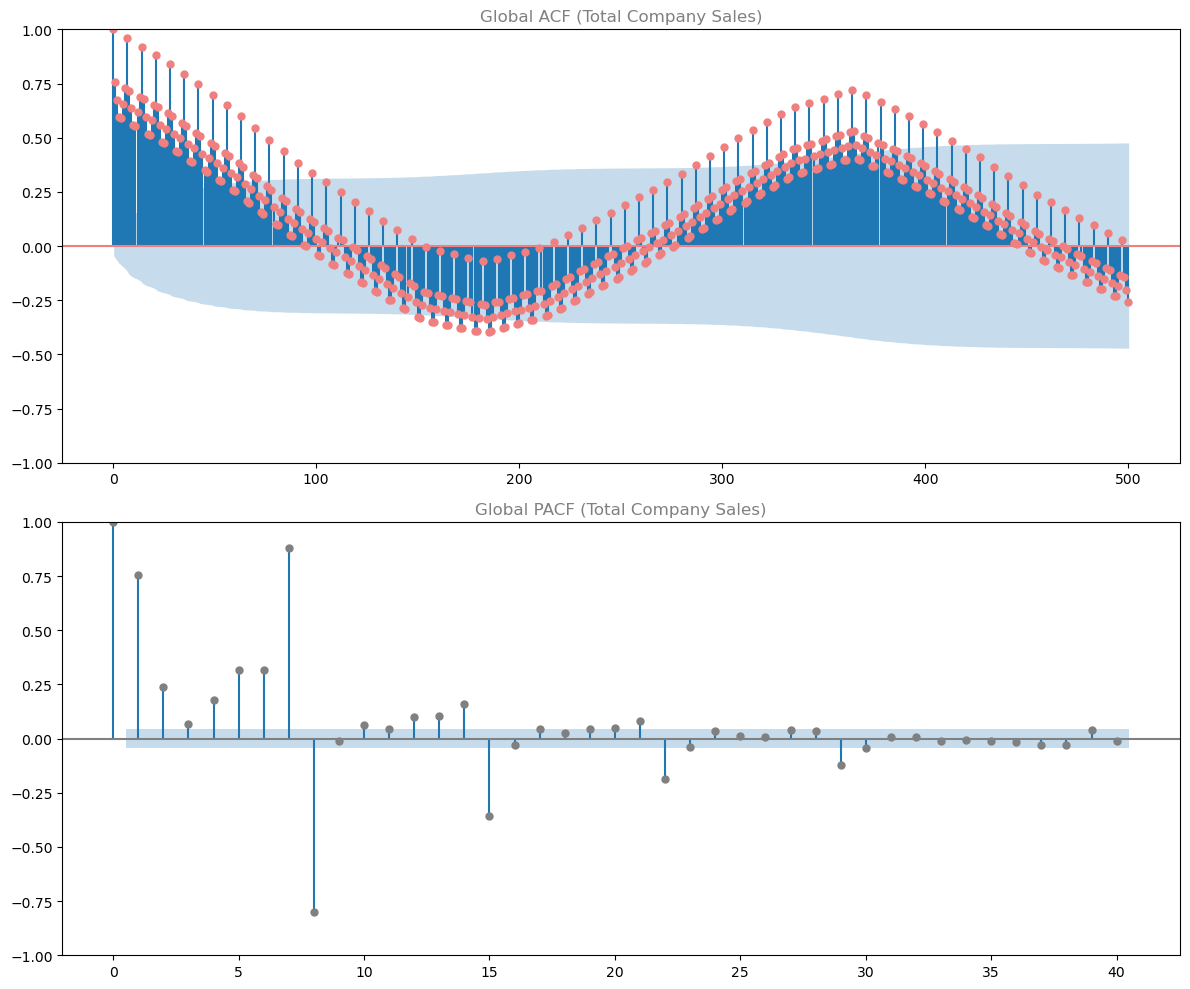

In [18]:
# Aggregate to company level
company_sales = df['sales'].resample('D').sum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# ACF: Shows the "seasonal" cycles (Look for spikes at 7, 14, 21...)
plot_acf(company_sales, lags=500, ax=ax1, color='#F08080')
ax1.set_title('Global ACF (Total Company Sales)', color='#808080')

# PACF: Shows which specific lags are truly unique/predictive
plot_pacf(company_sales, lags=40, ax=ax2, color='#808080')
ax2.set_title('Global PACF (Total Company Sales)', color='#808080')

plt.tight_layout()
plt.show()

**Conclusion:**
+ pacf: 1, 2, 7, 8 lagged features.
+ acf: 7 rolling (mean/std), 365 rolling mean

### is_holyday feature

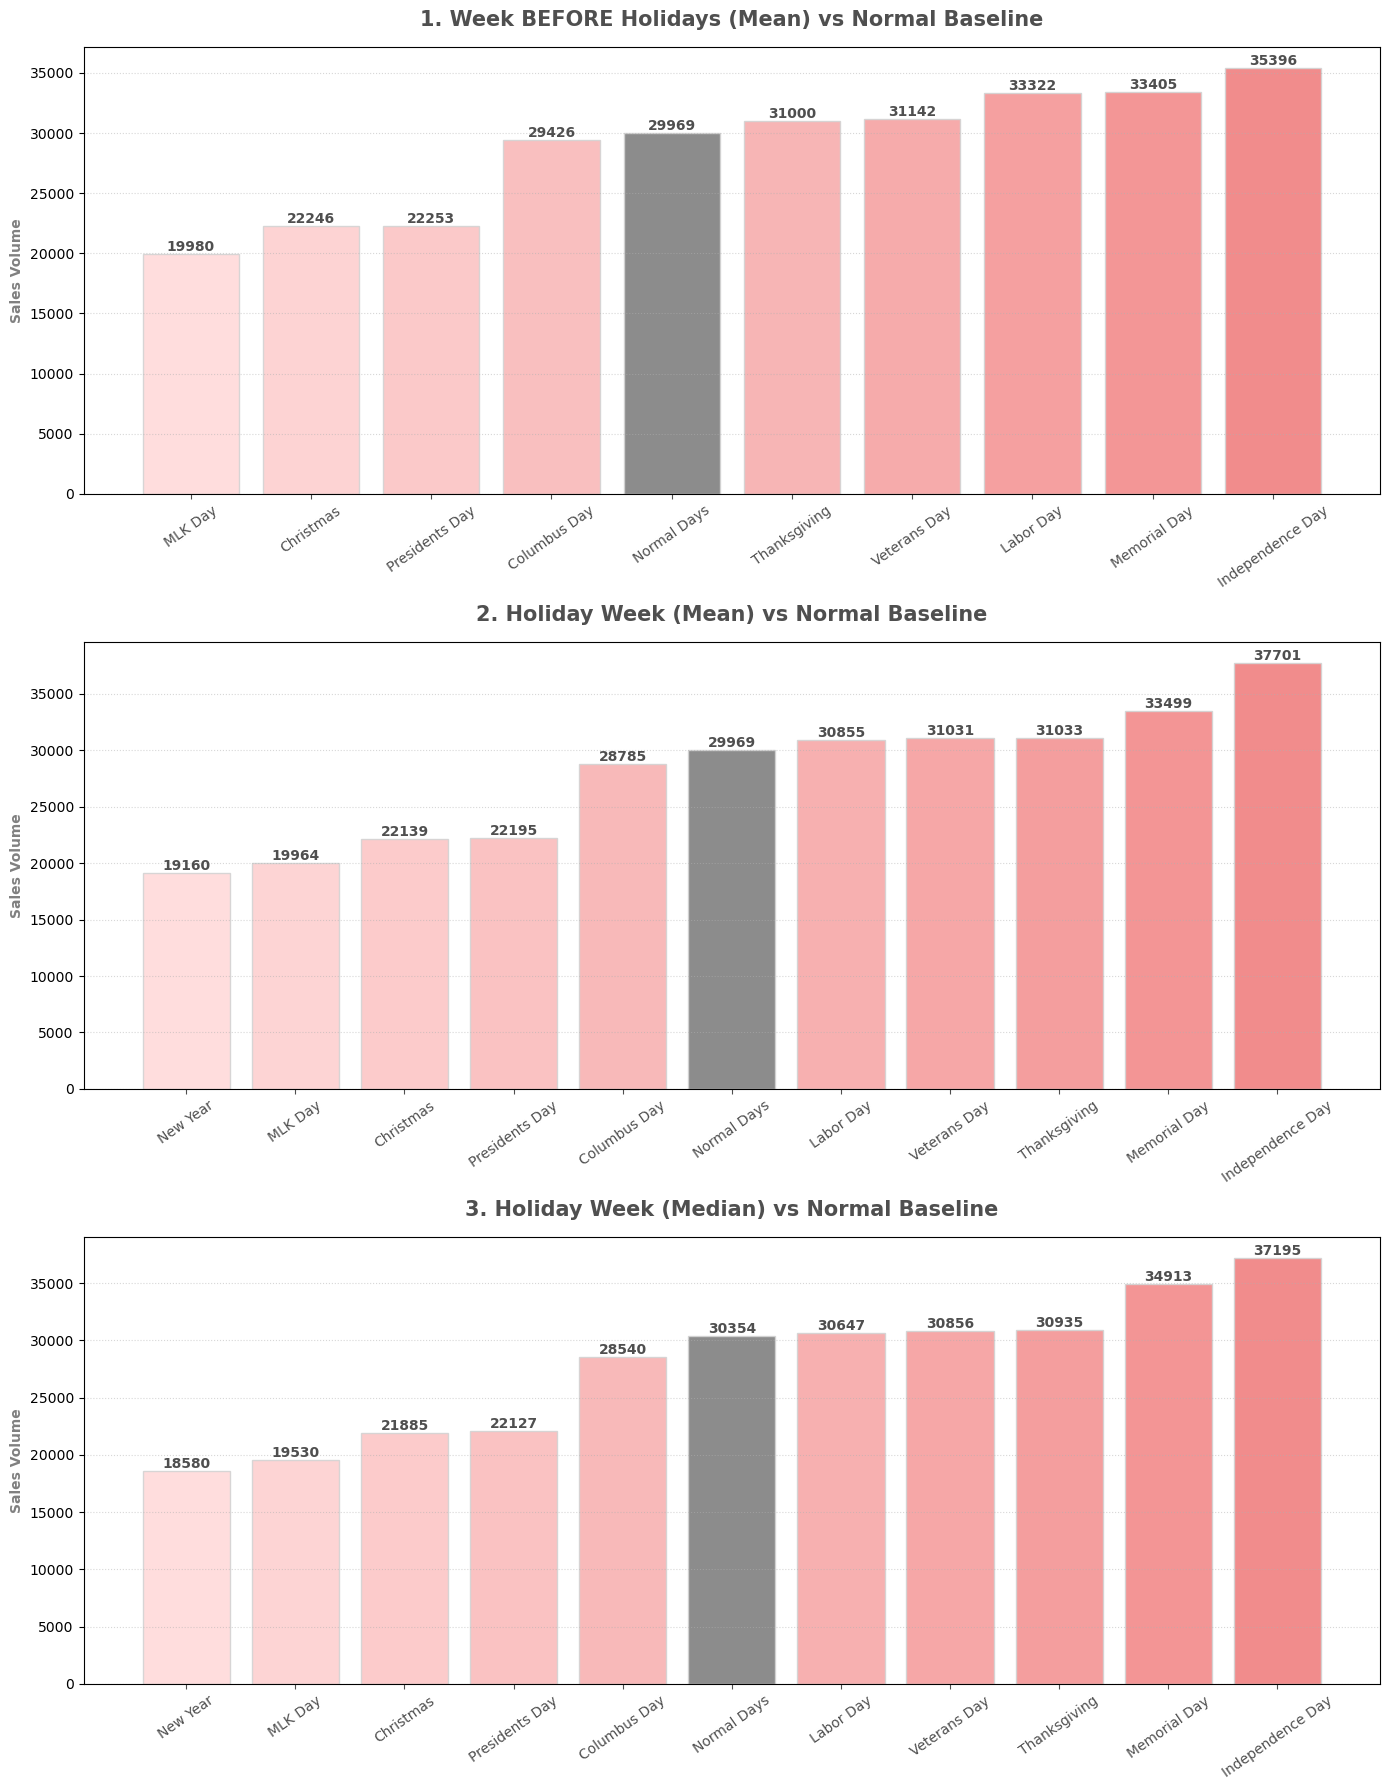

In [19]:
# 1. Aggregate daily sales and slice 2017
daily_sales = df['sales'].resample('D').sum()
df_2017 = daily_sales['2017']

# 2. Define Holidays and Time Windows
holidays_2017 = {
    'New Year': '2017-01-01', 'MLK Day': '2017-01-16', 'Presidents Day': '2017-02-20',
    'Memorial Day': '2017-05-29', 'Independence Day': '2017-07-04', 'Labor Day': '2017-09-04',
    'Columbus Day': '2017-10-09', 'Veterans Day': '2017-11-11', 'Thanksgiving': '2017-11-23',
    'Christmas': '2017-12-25'
}

h_windows, p_windows, excluded = {}, {}, []
for name, d in holidays_2017.items():
    center = pd.to_datetime(d)
    # Holiday: +/- 3 days | Pre-holiday: days -10 to -4
    h_s, h_e = center - pd.Timedelta(days=3), center + pd.Timedelta(days=3)
    p_s, p_e = center - pd.Timedelta(days=10), center - pd.Timedelta(days=4)
    
    # Filter empty windows to prevent NaN errors
    h_data, p_data = df_2017[h_s:h_e], df_2017[p_s:p_e]
    if not h_data.empty: h_windows[name] = h_data
    if not p_data.empty: p_windows[name] = p_data
    excluded.extend(pd.date_range(p_s, h_e))

# 3. Calculate Baseline
normal_days = df_2017.drop(pd.to_datetime(list(set(excluded))), errors='ignore')

# 4. Create Series for Plotting
s1 = pd.Series({**{n: w.mean() for n, w in p_windows.items()}, 'Normal Days': normal_days.mean()}).dropna().sort_values()
s2 = pd.Series({**{n: w.mean() for n, w in h_windows.items()}, 'Normal Days': normal_days.mean()}).dropna().sort_values()
s3 = pd.Series({**{n: w.median() for n, w in h_windows.items()}, 'Normal Days': normal_days.median()}).dropna().sort_values()

# 5. Gradient and Color Logic
red_cmap = mcolors.LinearSegmentedColormap.from_list("milk_red", ["#FFDADA", "#F08080"])

def get_bar_colors(series):
    n_hols = len(series) - 1
    # Generate gradient for holidays only
    gradient = [red_cmap(i/max(1, n_hols-1)) for i in range(n_hols)]
    cols, g_idx = [], 0
    for label in series.index:
        if label == 'Normal Days':
            cols.append('#808080') # Fixed Gray for Normal
        else:
            cols.append(gradient[g_idx])
            g_idx += 1
    return cols

# 6. Plotting
fig, axes = plt.subplots(3, 1, figsize=(14, 18), facecolor='white')

def draw_formatted_bars(ax, data, title):
    bar_cols = get_bar_colors(data)
    bars = ax.bar(data.index, data.values, color=bar_cols, edgecolor='#D3D3D3', alpha=0.9)
    ax.set_title(title, fontsize=15, color='#4F4F4F', fontweight='bold', pad=15)
    ax.set_ylabel('Sales Volume', color='#808080', fontweight='bold')
    ax.tick_params(axis='x', rotation=35, colors='#4F4F4F')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    
    for b in bars:
        h = b.get_height()
        if pd.notnull(h):
            ax.text(b.get_x() + b.get_width()/2, h, f'{int(h)}', 
                    ha='center', va='bottom', fontsize=10, fontweight='bold', color='#4F4F4F')

draw_formatted_bars(axes[0], s1, '1. Week BEFORE Holidays (Mean) vs Normal Baseline')
draw_formatted_bars(axes[1], s2, '2. Holiday Week (Mean) vs Normal Baseline')
draw_formatted_bars(axes[2], s3, '3. Holiday Week (Median) vs Normal Baseline')

plt.tight_layout()
plt.show()

In [20]:
# Compare the holiday week to the week IMMEDIATELY before it
thanksgiving_week = daily_sales['2017-11-20':'2017-11-26'].mean()
prior_week = daily_sales['2017-11-13':'2017-11-19'].mean()
print(f"Shift: {((thanksgiving_week / prior_week) - 1) * 100:.2f}%")

Shift: 0.11%


In [21]:
# strong evidence showing is_holyday feature is relevant.

### Preprocessing

### Feature Engineering

### Model Selection

### Using log transform

In [22]:
df= df.reset_index()

In [23]:
# 1. Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# 2. Chronological Splits
# 'train_full' is all history for feature generation
train_full = df[df['date'] < '2017-01-01'].copy()
# 'train_trimmed' removes 2013 to ensure lags have 365 days of history
train_trimmed = train_full[train_full['date'] >= '2014-01-01'].copy()
# 'test_df' is our unseen evaluation period
test_df = df[df['date'] >= '2017-01-01'].copy()

In [24]:
class AdvancedFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.stats = None
        self.holidays = None

    def fit(self, X, y=None):
        temp = X.copy()
        temp['sales'] = y if y is not None else 0
        # Calculate store-item means for filling NaNs
        self.stats = temp.groupby(['store', 'item'])['sales'].mean()
        cal = USFederalHolidayCalendar()
        self.holidays = cal.holidays(start=X['date'].min(), end=X['date'].max() + pd.Timedelta(days=730))
        return self

    def transform(self, X):
        # IMPORTANT: No .sort_values() here. We assume data is sorted before entry.
        X = X.copy()
        
        # Temporal Features
        X['day_of_week'] = X['date'].dt.dayofweek
        X['month_sin'] = np.sin(2 * np.pi * X['date'].dt.month / 12)
        X['month_cos'] = np.cos(2 * np.pi * X['date'].dt.month / 12)
        X['is_holiday'] = X['date'].isin(self.holidays).astype(int)

        # Autoregressive Features
        grouped = X.groupby(['store', 'item'])['sales']
        X['lag_1'] = grouped.shift(1)
        X['lag_2'] = grouped.shift(2)
        X['lag_7'] = grouped.shift(7)
        X['sales_diff'] = X['lag_1'] - X['lag_2']
        
        X['roll_mean_7'] = grouped.transform(lambda x: x.shift(1).rolling(7).mean())
        X['roll_mean_365'] = grouped.transform(lambda x: x.shift(1).rolling(365).mean())
        
        # Fill NaNs safely
        fill_values = X.set_index(['store', 'item']).index.map(self.stats).to_series()
        fill_values.index = X.index
        
        cols_to_fix = ['lag_1', 'lag_2', 'lag_7', 'sales_diff', 'roll_mean_7', 'roll_mean_365']
        for col in cols_to_fix:
            X[col] = X[col].fillna(fill_values).fillna(0)
            
        return X.drop(columns=['sales', 'date'], errors='ignore')

In [25]:
# 1. Setup Model & Pipeline
xgb_model = xgb.XGBRegressor(tree_method='hist', random_state=42)
log_model = TransformedTargetRegressor(regressor=xgb_model, func=np.log1p, inverse_func=np.expm1)

pipeline = Pipeline([
    ('engineer', AdvancedFeatureEngineer()),
    ('regressor', log_model)
])

# Expanded Search Space
param_dist = {
    'regressor__regressor__max_depth': [5, 7, 9], # Search deeper trees
    'regressor__regressor__learning_rate': [0.01, 0.05, 0.1], # Finer grain steps
    'regressor__regressor__n_estimators': [300,350, 500,600], # More boosting rounds
    'regressor__regressor__subsample': [0.8, 0.9], # Stochastic gradient boosting
    'regressor__regressor__colsample_bytree': [0.8, 0.9] # Feature subsampling
}

# 2. Pre-Sort
train_trimmed = train_trimmed.sort_values(['store', 'item', 'date'])
test_df = test_df.sort_values(['store', 'item', 'date'])

# 3. Fit with increased iterations
# n_iter=6 doubles the previous complexity (3 -> 6)
tscv = TimeSeriesSplit(n_splits=3)
search = RandomizedSearchCV(
    pipeline, 
    param_dist, 
    n_iter=6, 
    cv=tscv, 
    scoring='neg_root_mean_squared_error', 
    n_jobs=-1
)
search.fit(train_trimmed, train_trimmed['sales'])
best_model = search.best_estimator_

# 4. Recursive Loop (Remains same for index safety)
forecast_df = pd.concat([train_full.tail(365*500), test_df.copy()]).sort_values(['store', 'item', 'date'])
forecast_df.loc[test_df.index, 'sales'] = np.nan 

test_dates = sorted(test_df['date'].unique())

for current_date in test_dates:
    mask = (forecast_df['date'] == current_date)
    X_engineered = best_model.named_steps['engineer'].transform(forecast_df)
    X_current_day = X_engineered.loc[mask]
    day_preds = best_model.named_steps['regressor'].predict(X_current_day)
    forecast_df.loc[mask, 'sales'] = day_preds

# 5. Evaluation
final_preds = forecast_df.loc[test_df.index, 'sales']
rmse = np.sqrt(mean_squared_error(test_df['sales'], final_preds))

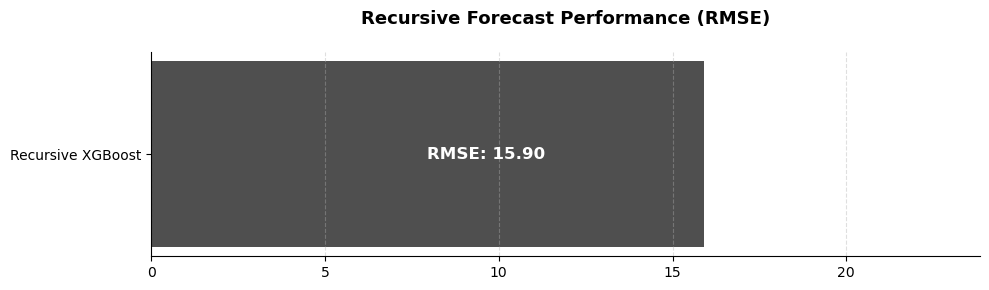

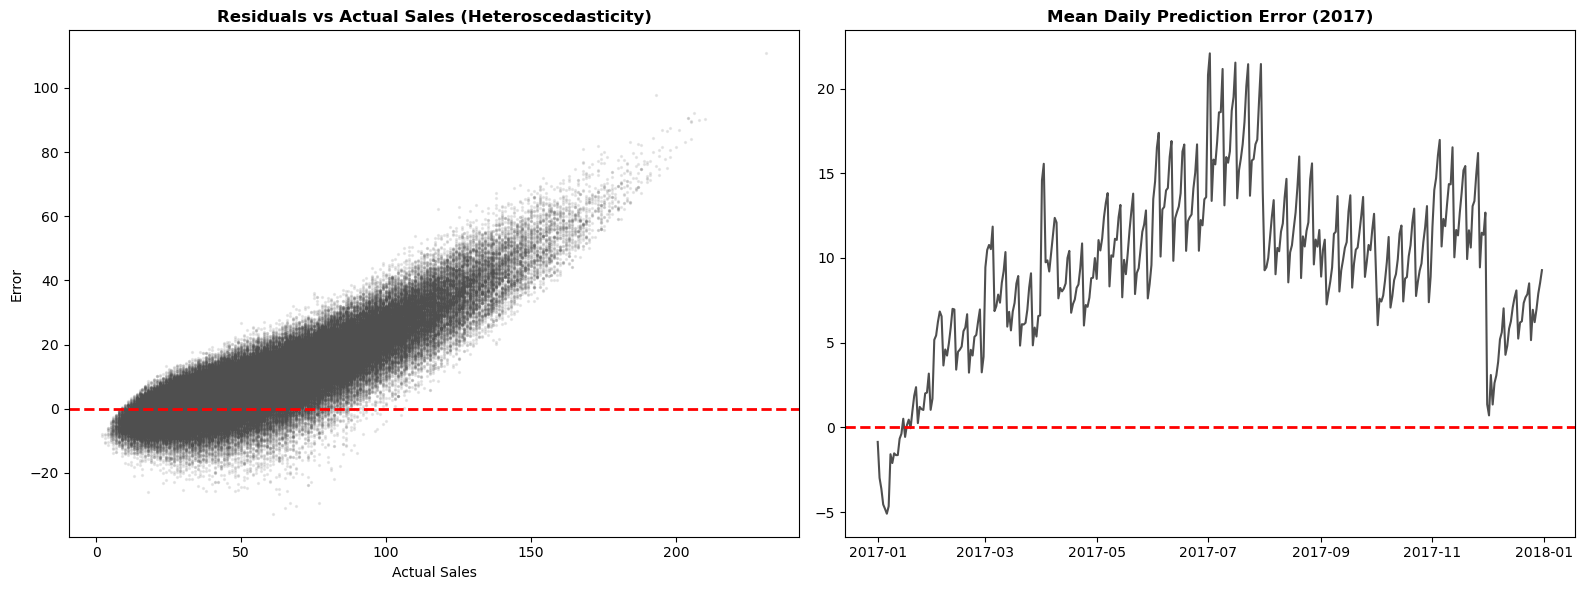

In [26]:
# --- RMSE HBAR ---
plt.figure(figsize=(10, 3))
plt.barh(['Recursive XGBoost'], [rmse], color='#4F4F4F', height=0.6)
plt.title('Recursive Forecast Performance (RMSE)', fontsize=13, fontweight='bold', pad=20)
plt.xlim(0, rmse * 1.5)
plt.grid(axis='x', linestyle='--', alpha=0.4)
# Display value inside bar
plt.text(rmse/2, 0, f'RMSE: {rmse:.2f}', color='white', va='center', fontweight='bold', fontsize=12)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# --- PARALLEL COORDINATES ---
cv_res = pd.DataFrame(search.cv_results_)
cv_res['RMSE'] = -cv_res['mean_test_score']
# Filter columns
cols = [c for c in cv_res.columns if 'param_regressor__regressor__' in c] + ['RMSE']
plot_df = cv_res[cols].copy()
plot_df.columns = [c.split('__')[-1] for c in plot_df.columns]

fig_pc = px.parallel_coordinates(
    plot_df, color='RMSE',
    labels={c: c.replace('_', ' ').title() for c in plot_df.columns},
    color_continuous_scale=px.colors.sequential.Greys,
    title="Hyperparameter Interaction & Score Map"
)
fig_pc.show()

# --- RESIDUALS ---
residuals = test_df['sales'] - final_preds
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Residuals vs Actuals
ax1.scatter(test_df['sales'], residuals, alpha=0.1, color='#4F4F4F', s=2)
ax1.axhline(0, color='red', linestyle='--', lw=2)
ax1.set_title("Residuals vs Actual Sales (Heteroscedasticity)", fontweight='bold')
ax1.set_xlabel("Actual Sales")
ax1.set_ylabel("Error")

# Mean Daily Residual
daily_err = pd.DataFrame({'date': test_df['date'], 'err': residuals}).groupby('date')['err'].mean()
ax2.plot(daily_err.index, daily_err.values, color='#4F4F4F', lw=1.5)
ax2.axhline(0, color='red', linestyle='--', lw=2)
ax2.set_title("Mean Daily Prediction Error (2017)", fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
def calculate_smape(actual, predicted):
    """
    Calculates the Symmetric Mean Absolute Percentage Error (SMAPE).
    Formula: (100/n) * sum(|F_t - A_t| / ((|A_t| + |F_t|)/2))
    """
    # Ensure inputs are numpy arrays
    actual, predicted = np.array(actual), np.array(predicted)
    
    # Calculate absolute differences and sums
    numerator = np.abs(predicted - actual)
    denominator = (np.abs(actual) + np.abs(predicted)) / 2
    
    # Calculate SMAPE (multiplied by 100 for percentage)
    smape_val = np.mean(numerator / denominator) * 100
    return smape_val

# Execute calculation on your test data
test_smape = calculate_smape(test_df['sales'], final_preds)

print(f"--- Model Evaluation ---")
print(f"RMSE:  {rmse:.4f}")
print(f"SMAPE: {test_smape:.4f}%")

--- Model Evaluation ---
RMSE:  15.8971
SMAPE: 18.8272%


### Forecasting

In [27]:
# sales / volatility

### Business Questions

##### item_level: ordering specific stock

In [28]:
residuals = test_df['sales'] - final_preds
error_std = np.std(residuals)

print(f"Daily Error Standard Deviation: {error_std:.2f}")
jan_2018_dates = pd.date_range(start='2018-01-01', end='2018-01-31')
stores, items = df['store'].unique(), df['item'].unique()

jan_grid = pd.MultiIndex.from_product(
    [jan_2018_dates, stores, items], 
    names=['date', 'store', 'item']
).to_frame(index=False)

# 2. Prepare Buffer (Ensures data is sorted for lag calculation)
jan_forecast_df = pd.concat([test_df.copy(), jan_grid]).sort_values(['store', 'item', 'date'])
jan_forecast_df.loc[jan_forecast_df['date'] >= '2018-01-01', 'sales'] = np.nan

# 3. Optimized Recursive Loop (Fixed Indexing & Speed)
for current_day in jan_2018_dates:
    mask = (jan_forecast_df['date'] == current_day)
    
    # Feature engineering for the whole buffer
    X_engineered = best_model.named_steps['engineer'].transform(jan_forecast_df)
    # Predict ONLY for the current day using .loc for index safety
    day_preds = best_model.named_steps['regressor'].predict(X_engineered.loc[mask])
    
    jan_forecast_df.loc[mask, 'sales'] = day_preds

# 4. Corrected Safety Buffer (Square Root of Time Rule)
jan_results = jan_forecast_df[jan_forecast_df['date'] >= '2018-01-01'].copy()
jan_results['predicted_sales'] = jan_results['sales']

# Group to Month Level
jan_summary = jan_results.groupby(['store', 'item'])['predicted_sales'].sum().reset_index()

# Monthly Uncertainty = Daily Error * sqrt(31 days)
monthly_error_std = error_std * np.sqrt(31)
jan_summary['safe_order_level'] = jan_summary['predicted_sales'] + (2 * monthly_error_std)

display(jan_summary.head())

Daily Error Standard Deviation: 12.76


,store,item,predicted_sales,safe_order_level
0,1,1,509.510120,651.565609
1,1,2,1358.910469,1500.965958
2,1,3,827.379444,969.434933
3,1,4,504.233780,646.289268
4,1,5,431.901560,573.957048


In [29]:
# 1. Extract January 2017 Actuals
jan_2017_actuals = df[(df['date'].dt.year == 2017) & (df['date'].dt.month == 1)].copy()
jan_2017_grouped = jan_2017_actuals.groupby(['store', 'item'])['sales'].sum().reset_index()
jan_2017_grouped.columns = ['store', 'item', 'actual_sales_jan_2017']

# 2. Merge with your Jan 2018 Forecast
# jan_summary now contains the corrected 3-digit safe order levels
comparison = pd.merge(jan_summary, jan_2017_grouped, on=['store', 'item'])

# 3. Calculate Year-over-Year (YoY) Growth
comparison['yoy_growth_pct'] = ((comparison['predicted_sales'] - comparison['actual_sales_jan_2017']) / 
                                comparison['actual_sales_jan_2017']) * 100

print("Business Insight: Jan 2018 Forecast vs. Jan 2017 Actuals")
display(comparison[['store', 'item', 'actual_sales_jan_2017', 'predicted_sales', 'yoy_growth_pct']].head())

Business Insight: Jan 2018 Forecast vs. Jan 2017 Actuals


,store,item,actual_sales_jan_2017,predicted_sales,yoy_growth_pct
0,1,1,485,509.510120,5.053633
1,1,2,1202,1358.910469,13.054116
2,1,3,788,827.379444,4.997391
3,1,4,488,504.233780,3.326594
4,1,5,407,431.901560,6.118319


**critical stockout flag**

In [30]:
# 1. Historical Daily Peak (January Only)
jan_history = df[df['date'].dt.month == 1].copy()
historical_max = jan_history.groupby(['store', 'item'])['sales'].max().reset_index()
historical_max.columns = ['store', 'item', 'hist_jan_max']

# 2. Forecasted Daily Peak
jan_daily_max = jan_results.groupby(['store', 'item'])['sales'].max().reset_index()
jan_daily_max.columns = ['store', 'item', 'forecast_daily_max']

# 3. Merge with the FIXED (3-digit) Monthly Summary
alerts = pd.merge(jan_summary, historical_max, on=['store', 'item'])
alerts = pd.merge(alerts, jan_daily_max, on=['store', 'item'])

# 4. LOGIC FIX: Buffered Risk Factor
# We calculate risk by asking: "Does our 95% Safe Daily Peak exceed the record?"
# Risk = (Forecasted Peak + 2 * Daily RMSE) / Historical Peak
alerts['risk_factor'] = (alerts['forecast_daily_max'] + (2 * error_std)) / alerts['hist_jan_max']

# 5. Filter for Critical Alerts
critical_stockouts = alerts[alerts['risk_factor'] > 1.15].sort_values('risk_factor', ascending=False)

if critical_stockouts.empty:
    print("✅ No capacity risks detected (Buffered peaks within 115% of records). Showing Top 5:")
    executive_view = alerts.sort_values('risk_factor', ascending=False).head(5).copy()
else:
    executive_view = critical_stockouts.head(5).copy()

# 6. Format for Executive Display
executive_view['Status'] = executive_view['risk_factor'].apply(lambda x: '🔴 CRITICAL' if x > 1.15 else '🟡 MONITOR')

# Selecting specific columns for clarity
executive_view = executive_view[['store', 'item', 'predicted_sales', 'safe_order_level', 'hist_jan_max', 'Status']]
executive_view.columns = ['Store ID', 'Item ID', 'Jan Monthly Forecast', 'Safe Monthly Stock', 'Hist Daily Record', 'Alert Status']

display(executive_view)

,Store ID,Item ID,Jan Monthly Forecast,Safe Monthly Stock,Hist Daily Record,Alert Status
204,5,5,362.828288,504.883777,18,🔴 CRITICAL
276,6,27,434.529328,576.584817,20,🔴 CRITICAL
290,6,41,431.330561,573.386049,21,🔴 CRITICAL
303,7,4,379.053412,521.108901,20,🔴 CRITICAL
340,7,41,369.802202,511.857691,20,🔴 CRITICAL


In [31]:
# 1. Aggregate Daily Store Load
# We sum the predicted sales for all items within each store for each day
store_daily_load = jan_results.groupby(['date', 'store'])['sales'].sum().reset_index()

# 2. LOGIC FIX: Store-Specific Thresholds
# A busy store and a small store shouldn't share the same threshold.
# We define 'Peak' as 1.5 Standard Deviations above that specific store's mean.
store_stats = store_daily_load.groupby('store')['sales'].agg(['mean', 'std']).reset_index()
store_daily_load = store_daily_load.merge(store_stats, on='store')

# Peak Day = Current Load > (Store Mean + 1.5 * Store Std Dev)
store_daily_load['is_peak'] = store_daily_load['sales'] > (store_daily_load['mean'] + 1.5 * store_daily_load['std'])

# 3. Filter for High-Load Days
staffing_alerts = store_daily_load[store_daily_load['is_peak']].copy()

# 4. Add Contextual Metadata
staffing_alerts['Day_Name'] = staffing_alerts['date'].dt.day_name()
staffing_alerts['Staffing_Requirement'] = '⬆️ HIGH (Deploy Extra Shifts)'

# 5. Executive Dashboard
staffing_dashboard = staffing_alerts[['date', 'store', 'sales', 'Day_Name', 'Staffing_Requirement']]
staffing_dashboard.columns = ['Date', 'Store ID', 'Total Predicted Units', 'Weekday', 'Action Plan']

display(staffing_dashboard.sort_values(by=['Date', 'Store ID']).head(10))

,Date,Store ID,Total Predicted Units,Weekday,Action Plan
60,2018-01-07,1,2257.659304,Sunday,⬆️ HIGH (Deploy Extra Shifts)
61,2018-01-07,2,3125.484823,Sunday,⬆️ HIGH (Deploy Extra Shifts)
62,2018-01-07,3,2832.936382,Sunday,⬆️ HIGH (Deploy Extra Shifts)
63,2018-01-07,4,2627.006819,Sunday,⬆️ HIGH (Deploy Extra Shifts)
64,2018-01-07,5,1914.697056,Sunday,⬆️ HIGH (Deploy Extra Shifts)
65,2018-01-07,6,1910.213296,Sunday,⬆️ HIGH (Deploy Extra Shifts)
66,2018-01-07,7,1751.628737,Sunday,⬆️ HIGH (Deploy Extra Shifts)
67,2018-01-07,8,3001.292528,Sunday,⬆️ HIGH (Deploy Extra Shifts)
68,2018-01-07,9,2614.171663,Sunday,⬆️ HIGH (Deploy Extra Shifts)
69,2018-01-07,10,2758.622982,Sunday,⬆️ HIGH (Deploy Extra Shifts)


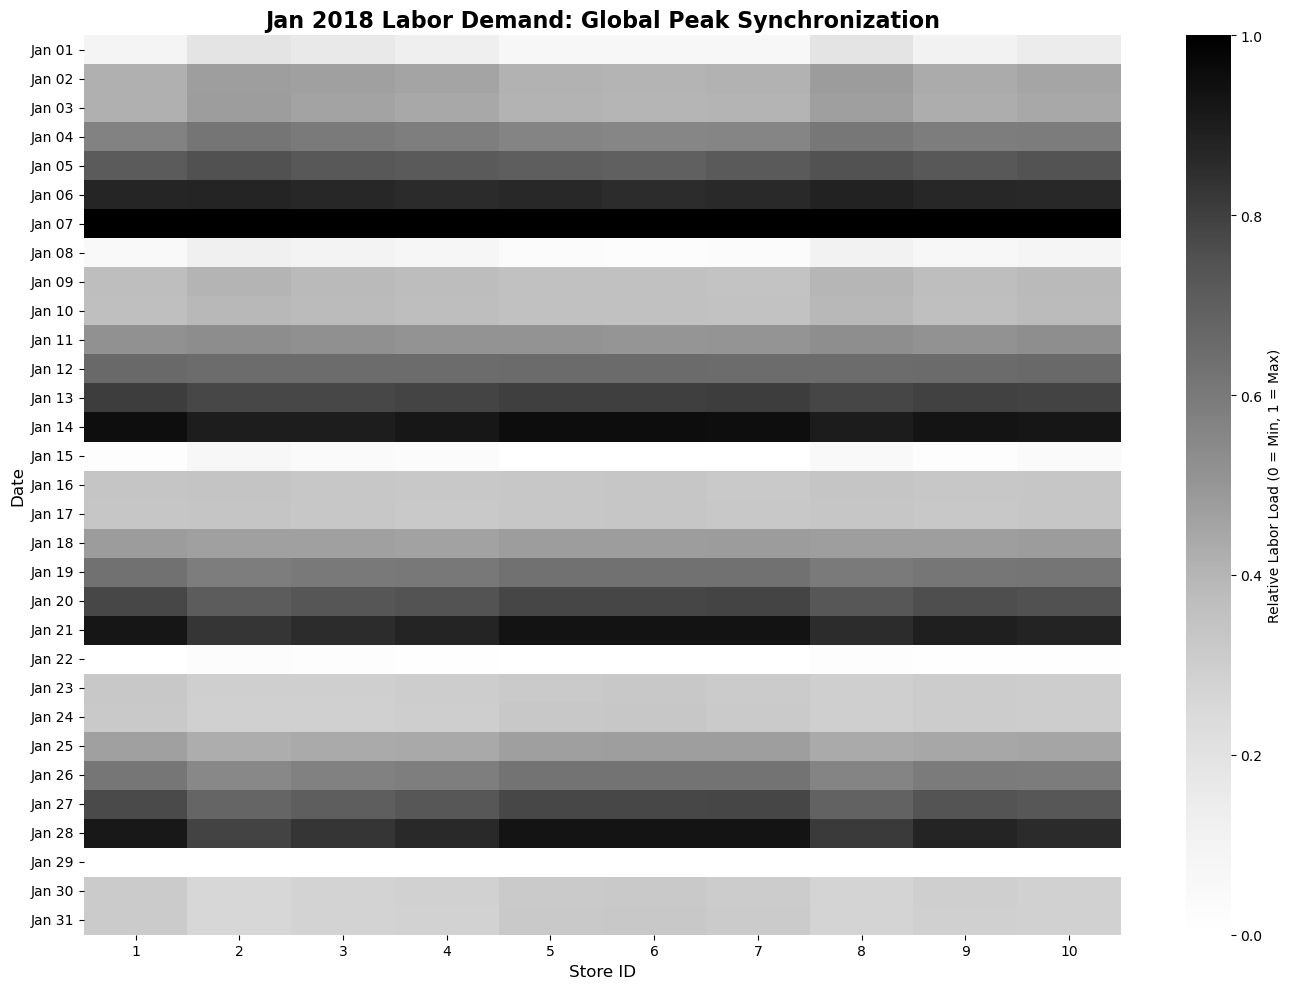

In [32]:
# 1. Logic Fix: Use Min-Max Scaling per store 
# This ensures every store's busiest day is 'Black' and quietest is 'White'
# This allows us to see the global "Weekend" peaks you mentioned across all stores.
store_daily_load['normalized_load'] = store_daily_load.groupby('store')['sales'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

# 2. Pivot for Heatmap
pivot_load = store_daily_load.pivot(index='date', columns='store', values='normalized_load')

# 3. Format Date labels
pivot_load.index = pivot_load.index.strftime('%b %d')

# 4. Visualization
plt.figure(figsize=(14, 10))
sns.heatmap(
    pivot_load, 
    cmap='Greys',      # Grayscale gradient
    linewidths=0,      # Removed the white lines
    cbar_kws={'label': 'Relative Labor Load (0 = Min, 1 = Max)'}
)

plt.title("Jan 2018 Labor Demand: Global Peak Synchronization", fontweight='bold', fontsize=16)
plt.xlabel("Store ID", fontsize=12)
plt.ylabel("Date", fontsize=12)

plt.tight_layout()
plt.show()

**High expected traffic for staffing management**

**Global level: company growth**

In [33]:
# 1. Store-Level Comparison
store_jan_2018 = jan_results.groupby('store')['sales'].sum()
# Filter for Jan 2017 Actuals
jan_2017_mask = (df['date'].dt.year == 2017) & (df['date'].dt.month == 1)
store_jan_2017 = df[jan_2017_mask].groupby('store')['sales'].sum()

store_performance = pd.DataFrame({
    'sales_jan_2017': store_jan_2017,
    'forecast_jan_2018': store_jan_2018
}).reset_index()

# 2. Calculate YoY Growth Rate
store_performance['yoy_growth_pct'] = ((store_performance['forecast_jan_2018'] - store_performance['sales_jan_2017']) / 
                                       store_performance['sales_jan_2017']) * 100

# 3. LOGIC FIX: Revised Categorization
# We add a 'Flat' category for growth between -1% and 1% to account for model noise
def categorize_growth(val):
    if val > 5: return '🟢 Booming'
    elif val >= 1: return '🟡 Growing'
    elif val >= -1: return '⚪ Flat'
    else: return '🔴 Declining'

store_performance['Status'] = store_performance['yoy_growth_pct'].apply(categorize_growth)

# 4. LOGIC FIX: Confidence Level (Precision-based)
# Confidence is 1 - (RMSE / Mean Sales of the Test Set)
# This specifically measures how well we predicted the most recent year
test_mean = test_df['sales'].mean()
precision = 1 - (rmse / test_mean)
confidence_pct = max(0, precision * 100) # Ensure it doesn't go negative

# 5. Global Metrics
total_jan_17 = store_performance['sales_jan_2017'].sum()
total_jan_18 = store_performance['forecast_jan_2018'].sum()
global_growth = ((total_jan_18 - total_jan_17) / total_jan_17) * 100

# --- Display Results ---
print(f"--- GLOBAL BUSINESS HEALTH (JANUARY) ---")
print(f"Total Portfolio Growth: {global_growth:.2f}%")
print(f"Forecast Precision Level: {confidence_pct:.1f}%\n")

print("--- STORE-BY-STORE SUMMARY ---")
# Resetting index to show Store ID clearly
display(store_performance[['store', 'yoy_growth_pct', 'Status']].sort_values('yoy_growth_pct', ascending=False).set_index('store'))

--- GLOBAL BUSINESS HEALTH (JANUARY) ---
Total Portfolio Growth: 2.76%
Forecast Precision Level: 73.0%

--- STORE-BY-STORE SUMMARY ---


,yoy_growth_pct,Status
store,,
7,6.163898,🟢 Booming
5,5.941584,🟢 Booming
6,5.387079,🟢 Booming
1,4.129107,🟡 Growing
4,3.237297,🟡 Growing
9,2.286105,🟡 Growing
10,1.671955,🟡 Growing
3,1.439146,🟡 Growing
8,0.935257,⚪ Flat


In [35]:
# --- STEP 1: GAP CHECK & GRID ALIGNMENT ---
# Load original test data
test_raw = pd.read_csv('test.csv', parse_dates=['date'])

# Generate every possible combination to ensure no missing dates/items
all_dates = pd.date_range(start=test_raw['date'].min(), end=test_raw['date'].max(), freq='D')
all_stores = test_raw['store'].unique()
all_items = test_raw['item'].unique()

perfect_grid = pd.MultiIndex.from_product(
    [all_dates, all_stores, all_items], 
    names=['date', 'store', 'item']
).to_frame(index=False)

# Merge raw test into grid. missing rows appear as NaN 'id'
test_complete = pd.merge(perfect_grid, test_raw, on=['date', 'store', 'item'], how='left')

# Fill missing IDs with -1 so it stays an integer/float column
test_complete['id'] = test_complete['id'].fillna(-1)

# --- STEP 2: PREPARE RECURSIVE BUFFER ---
# Combine history (train) + test_complete
# We use tail(500 * 365) to get 1 year of history for all 500 store-item pairs
history_needed = train_full.tail(500 * 365).copy() 
forecast_df = pd.concat([history_needed, test_complete], sort=False).sort_values(['store', 'item', 'date'])

# Set sales to NaN for the test period
forecast_df.loc[forecast_df['date'] >= test_raw['date'].min(), 'sales'] = np.nan

# --- STEP 3: RECURSIVE LOOP (FIXED) ---
test_dates = sorted(test_raw['date'].unique())

for current_date in test_dates:
    mask = (forecast_df['date'] == current_date)
    
    # 1. Transform features for the current state
    X_engineered = best_model.named_steps['engineer'].transform(forecast_df)
    
    # 2. SELECT ONLY the rows for today
    X_current_day = X_engineered.loc[mask].copy()
    
    # 3. LOGIC FIX: Drop 'id' if it exists to match training features
    if 'id' in X_current_day.columns:
        X_current_day = X_current_day.drop(columns=['id'])
    
    # 4. Predict
    preds = best_model.named_steps['regressor'].predict(X_current_day)
    
    # 5. Update the main buffer
    forecast_df.loc[mask, 'sales'] = preds

# --- STEP 4: EXPORT ---
final_predictions = forecast_df[forecast_df['date'] >= test_raw['date'].min()].copy()

# Ensure we output the original 'id' column as an integer
output = pd.DataFrame({
    'id': final_predictions['id'].astype(int),
    'sales': final_predictions['sales']
})

# Filter out the -1 rows if gaps actually existed (Kaggle won't accept them)
output = output[output['id'] != -1]

output.to_csv('predictions.csv', index=False)
print("✅ Done! predictions.csv generated with no gaps.")

✅ Done! predictions.csv generated with no gaps.
